# TADs Heterogeneity Analysis

Analysis of TAD border heterogeneity and similarity within and between schizophrenia and healthy control groups.

In [ ]:
import pandas as pd
import numpy as np
import bioframe as bf
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt
from os import listdir
import os
import seaborn as sns
from pybedtools import BedTool
from scipy.stats import mannwhitneyu, ttest_ind
import re
from itertools import combinations
import matplotlib as mpl

In [2]:
merged_bed = pd.read_pickle("./tads_additional_files/merged_bed_with_tads_clustering_neurons.pickle")

In [ ]:
resolution_kb = 15 
res = f"_{resolution_kb}res"
path_to_tads = '/tank/projects/diana_hic/sz_project2024/4.tads_borders/tads_borders_layouts/'
tads = [f for f in listdir(path_to_tads) if "tad_borders_" in f]
tads = [f for f in tads if "15res" in f and '150wind' in f]
tads = [f for f in tads if "merge" not in f]

tads.sort()
len(tads)
tads

hc_tads = [os.path.join(path_to_tads, f) for f in tads if 'HC' in f]
sz_tads = [os.path.join(path_to_tads, f) for f in tads if 'SZ' in f]

In [ ]:
location = path_to_tads
tads = [
    'tad_borders_HC-2Mplus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_HC-318plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_HC-3Mplus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_HC-91plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_HC24plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_HCM12plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ-01plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ-03plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ08plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ10plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ20plus_sampled_drop_diag_15res_150wind.bed',
    'tad_borders_SZ6plus_sampled_drop_diag_15res_150wind.bed'
]
bin_size = 15000
expand_bp = int(1.5 * bin_size)

def expand_bed(input_bed, output_bed, expand_bp):
    with open(input_bed) as fin, open(output_bed, 'w') as fout:
        for line in fin:
            if line.startswith('#') or line.strip() == '':
                continue
            chrom, start, end = line.strip().split()[:3]
            start = max(0, int(start) - expand_bp)
            end = int(end) + expand_bp
            fout.write(f"{chrom}\t{start}\t{end}\n")

expanded_beds = []
for tad in tads:
    input_bed = os.path.join(location, tad)
    output_bed = os.path.join(location, tad.replace('.bed', f'_expanded_{expand_bp}.bed'))
    expand_bed(input_bed, output_bed, expand_bp)
    expanded_beds.append(output_bed)

hc_beds = [b for b in expanded_beds if 'HC' in b]
sz_beds = [b for b in expanded_beds if 'SZ' in b]
all_beds =[b for b in expanded_beds]

## BP-based Jaccard Analysis

In [ ]:
def pairwise_jaccard(bed_files):
    n = len(bed_files)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                a = BedTool(bed_files[i])
                b = BedTool(bed_files[j])
                jaccard = a.jaccard(b)['jaccard']
                matrix[i, j] = jaccard
                matrix[j, i] = jaccard 
    return matrix

hc_matrix = pairwise_jaccard(hc_beds)
sz_matrix = pairwise_jaccard(sz_beds)

In [222]:
all_matrix = pairwise_set_jaccard(all_beds)

In [ ]:
def extract_sample_name(filename):
    match = filename.split('tad_borders_')[1].split('plus')[0]
    if match:
        return match
    else:
        return filename

def plot_heatmap(matrix, labels, title):
    df = pd.DataFrame(matrix, index=labels, columns=labels)
    min_val = np.min(matrix)
    max_val = 0.6
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        df,
        annot=True,
        cmap='YlGnBu',
        vmin=min_val,
        vmax=max_val,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Jaccard Index"}
    )
    plt.title(title, fontsize=16)
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

hc_labels = [extract_sample_name(os.path.basename(f)) for f in hc_beds]
sz_labels = [extract_sample_name(os.path.basename(f)) for f in sz_beds]

plot_heatmap(hc_matrix, hc_labels, 'HC TAD Border Similarity')
plot_heatmap(sz_matrix, sz_labels, 'SZ TAD Border Similarity')

In [223]:
all_labels = [extract_sample_name(os.path.basename(f)) for f in all_beds]

In [ ]:
def make_label(label):
    age = samples_with_age[label]
    group = age_group[label]
    short = label
    return f"{short}\n{age}y\n{group}"

def plot_clustermap(matrix, labels, title, samples_with_age, figsize=(8, 8)):
    annotated_labels = [make_label(lab) for lab in labels]
    distance_matrix = matrix
    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)
    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]
    min_val = np.min(sorted_matrix)
    max_val = 1
    df = pd.DataFrame(distance_matrix, index=annotated_labels, columns=annotated_labels)
    cg = sns.clustermap(
        df,
        cmap='YlGnBu',
        linewidths=0.5,
        figsize=figsize,
        vmin=min_val,
        vmax=max_val,
        annot=True,
        cbar_kws={"label": "Jaccard"},
        metric='euclidean',
        method='average',
    )
    plt.show()

plot_clustermap(all_matrix, all_labels, 'All samples TAD Borders Set-based Jaccard\nNeurons', samples_with_age, figsize=(10, 10))

In [ ]:
def get_off_diagonal(matrix):
    n = matrix.shape[0]
    return [matrix[i, j] for i in range(n) for j in range(n) if i != j]

hc_similarities = get_off_diagonal(hc_matrix)
sz_similarities = get_off_diagonal(sz_matrix)
stat, p_value = mannwhitneyu(hc_similarities, sz_similarities, alternative='two-sided')

In [ ]:
data = [hc_similarities, sz_similarities]
labels = ['HC', 'SZ']
stat, p_value = mannwhitneyu(hc_similarities, sz_similarities, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.3f}")
print(f"p-value: {p_value:.3e}")

print(f"HC mean: {np.mean(hc_similarities):.3f}, median: {np.median(hc_similarities):.3f}")
print(f"SZ mean: {np.mean(sz_similarities):.3f}, median: {np.median(sz_similarities):.3f}")

plt.figure(figsize=(3, 4))
sns.boxplot(
    data=data,
    showmeans=True,
    width=0.4,
    palette='Set2',
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    }
)
plt.xticks([0, 1], labels)
plt.ylabel('Pairwise Jaccard Index')
plt.title('TAD Border Similarity Distribution')

plt.text(0.5, max(max(hc_similarities), max(sz_similarities)) + 0.017,
         f'p = {round(p_value, 2)}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## Set-based Jaccard Analysis

In [ ]:
def extract_sample_name(filename):
    match = filename.split('tad_borders_')[1].split('plus')[0]
    if match:
        return match
    else:
        return filename

def set_jaccard(bedA, bedB):
    A = BedTool(bedA)
    B = BedTool(bedB)
    overlaps_A = A.intersect(B, u=True)
    overlaps_B = B.intersect(A, u=True)
    n_overlaps = len(overlaps_A)
    n_A = len(A)
    n_B = len(B)
    n_union = n_A + n_B - n_overlaps
    jaccard = n_overlaps / n_union if n_union > 0 else 0
    return jaccard

def pairwise_set_jaccard(bed_files):
    n = len(bed_files)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                jac = set_jaccard(bed_files[i], bed_files[j])
                matrix[i, j] = jac
                matrix[j, i] = jac
    return matrix

def plot_heatmap(matrix, labels, title):
    df = pd.DataFrame(matrix, index=labels, columns=labels)
    min_val = 0.6
    max_val = 0.8
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        df,
        annot=True,
        cmap='YlGnBu',
        vmin=min_val,
        vmax=max_val,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Set-based Jaccard Index"}
    )
    plt.title(title, fontsize=16)
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def get_off_diagonal(matrix):
    n = matrix.shape[0]
    return [matrix[i, j] for i in range(n) for j in range(n) if i != j]

In [ ]:
samples_with_age = {
    'HC-2M': 62,
    'HC-3M': 36,
    'HC-91': 59,
    'HC24': 54,
    'HC-318': 58,
    'HCM12': 35,
    'SZ-01': 36,
    'SZ-03': 57,
    'SZ08': 56,
    'SZ10': 50,
    'SZ20': 37,
    'SZ6': 62
}
age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Adult"
    elif 40 < age:
        age_group[label] = "Old"

def extract_sample_name(filename):
    core = filename.split('tad_borders_')[1].split('plus')[0]
    core = core.rstrip('_')
    return core

def get_sorted_labels_and_indices(labels, samples_with_age):
    paired = [(label, samples_with_age[label]) for label in labels]
    paired_sorted = sorted(paired, key=lambda x: x[1])
    sorted_labels = [p[0] for p in paired_sorted]
    sorted_indices = [labels.index(lab) for lab in sorted_labels]
    return sorted_labels, sorted_indices

def make_label(label):
    age = samples_with_age[label]
    group = age_group[label]
    short = label
    return f"{short}\n{age}y\n{group}"

def plot_heatmap(matrix, labels, title, samples_with_age, figsize=(6, 5)):
    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)
    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]
    annotated_labels = [make_label(lab) for lab in sorted_labels]
    df = pd.DataFrame(sorted_matrix, index=annotated_labels, columns=annotated_labels)
    min_val = np.min(sorted_matrix)
    max_val = np.max(sorted_matrix)
    plt.figure(figsize=figsize)
    sns.heatmap(
        df,
        annot=True,
        cmap='YlGnBu',
        vmin=min_val,
        vmax=max_val,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Set-based Jaccard Index"}
    )
    plt.title(title, fontsize=16)
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

hc_labels = [extract_sample_name(os.path.basename(f)) for f in hc_beds]
sz_labels = [extract_sample_name(os.path.basename(f)) for f in sz_beds]

plot_heatmap(hc_matrix, hc_labels, 'HC TAD Border Set-based Jaccard', samples_with_age)
plot_heatmap(sz_matrix, sz_labels, 'SZ TAD Border Set-based Jaccard', samples_with_age)

### Set-based (All Samples)

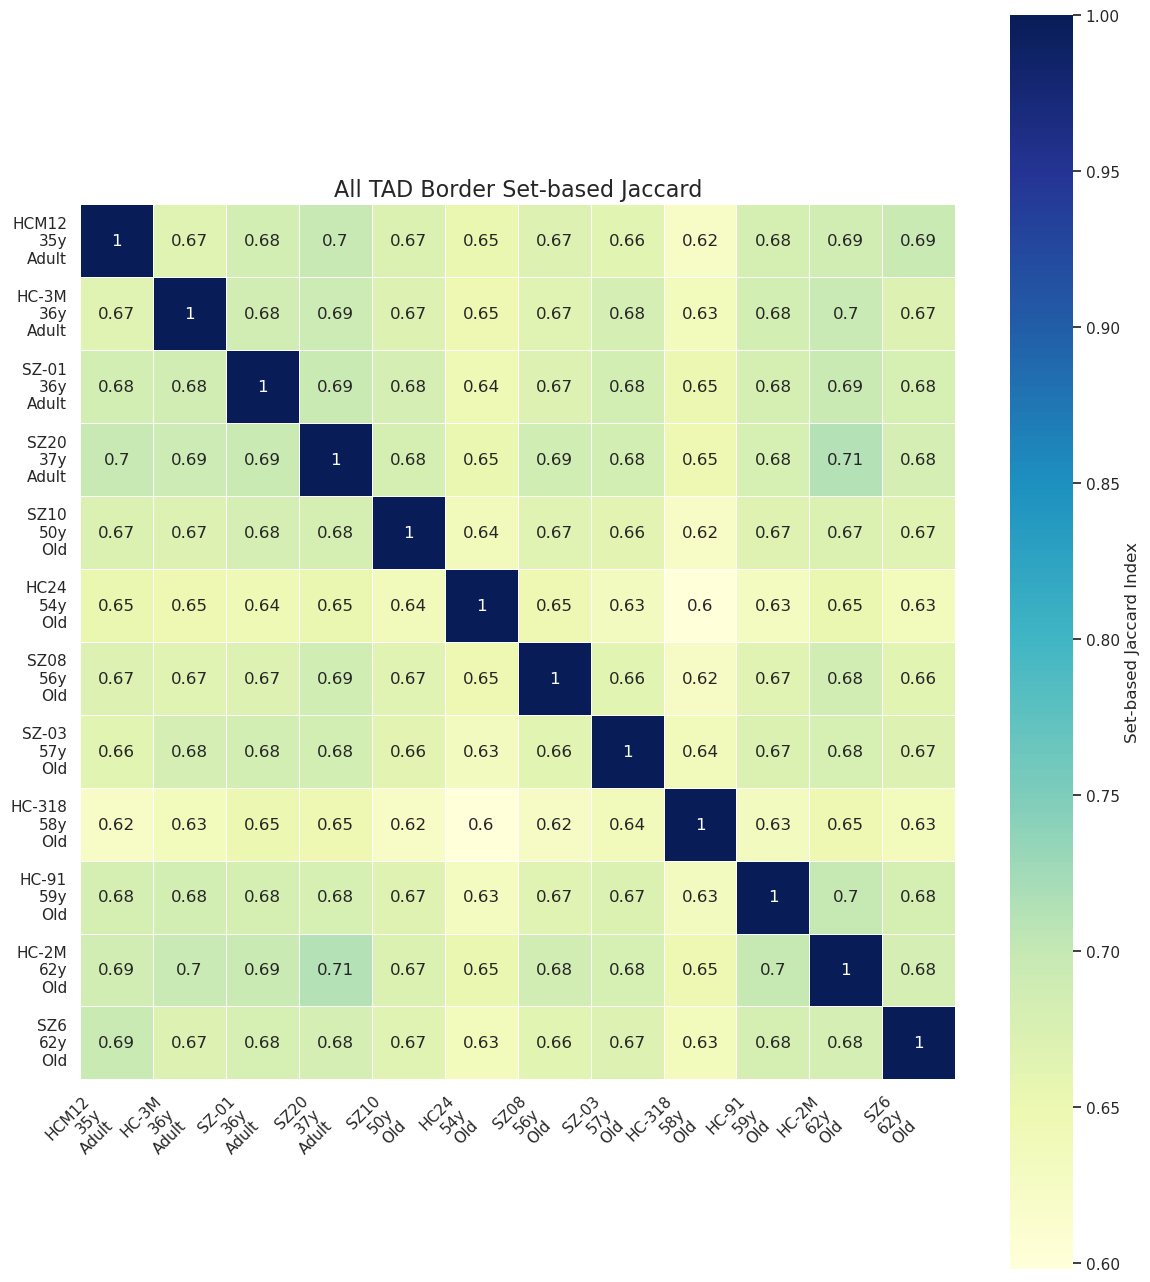

In [244]:
all_matrix_set = pairwise_set_jaccard(all_beds)
all_labels_set = [extract_sample_name(os.path.basename(f)) for f in all_beds]
plot_heatmap(all_matrix_set, all_labels_set, 'All TAD Border Set-based Jaccard', samples_with_age, figsize=(12,13))


In [ ]:
def get_group(label):
    if label.startswith('HC'):
        return 'HC'
    elif label.startswith('SZ'):
        return 'SZ'
    else:
        return 'Other'

def significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

groups = [get_group(label) for label in all_labels_set]

In [ ]:
data = []
n = len(all_labels_set)
for i in range(n):
    for j in range(i+1, n):
        sim = all_matrix_set[i, j]
        group_i = groups[i]
        group_j = groups[j]
        if group_i == group_j == 'HC':
            cat = 'Within HC'
        elif group_i == group_j == 'SZ':
            cat = 'Within SZ'
        elif (group_i == 'HC' and group_j == 'SZ') or (group_i == 'SZ' and group_j == 'HC'):
            cat = 'Between HC-SZ'
        else:
            continue
        data.append({'similarity': sim, 'category': cat})

df = pd.DataFrame(data)
order = ['Within HC', 'Within SZ', 'Between HC-SZ']


In [ ]:
my_pal = {
    "Within HC": '#469433',
    "Within SZ":  '#e38519',
    "Between HC-SZ": "lightgrey"
}

cat_labels = ['Within HC', 'Within SZ', 'Between HC-SZ']
pvals = {}
for cat1, cat2 in combinations(cat_labels, 2):
    group1 = df[df['category'] == cat1]['similarity']
    group2 = df[df['category'] == cat2]['similarity']
    stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
    pvals[(cat1, cat2)] = pval

sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
plt.rcParams["svg.fonttype"] = "none"

plt.figure(figsize=( 3.5, 6.54))
ax = sns.boxplot(
    x='category', y='similarity', data=df, order=order,
    palette=my_pal, showfliers=False, linewidth=0.4, width=0.4,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "grey",
        "markersize": 6,
        "markeredgewidth": 2
    }
)

ax.set_xlabel('')
ax.set_ylabel('Jaccard Similarity', labelpad=10)
ax.set_ylim(0.5, 0.76)

y_max = df['similarity'].max()
y_min = df['similarity'].min()
y_min=0.4
h = (y_max - y_min) * 0.02

pairs = [
    (0, 1),
    (0, 2),
    (1, 2)
]
for idx, ((cat1, cat2), (i, j)) in enumerate(zip(pvals.keys(), pairs)):
    y = y_max + h*idx
    x1, x2 = i, j
    pval = pvals[(cat1, cat2)]
    label = significance_label(pval) + f" (p={round(pval,2)})"
    ax.plot([x1, x1, x2, x2], [y, y+h/4, y+h/4, y], lw=0.4, c='k')
    ax.text((x1+x2)/2, y+h/4, label, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
cell_type = "neurons"
plt.savefig(f'./tads_visualizations/{cell_type}_jaccard_similarity_groups_pubready.svg', dpi=300)
plt.savefig(f'./tads_visualizations/{cell_type}_jaccard_similarity_groups_pubready.pdf', dpi=300)

plt.show()

### Set-based (Individual) with Cluster Maps

/opt/anaconda/lib/python3.9/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


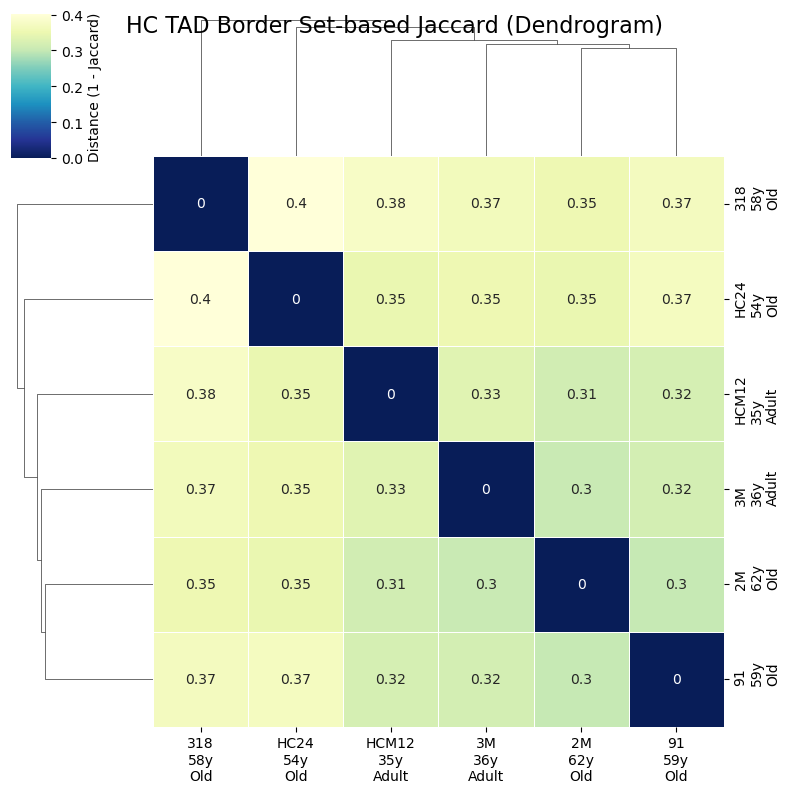

/opt/anaconda/lib/python3.9/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


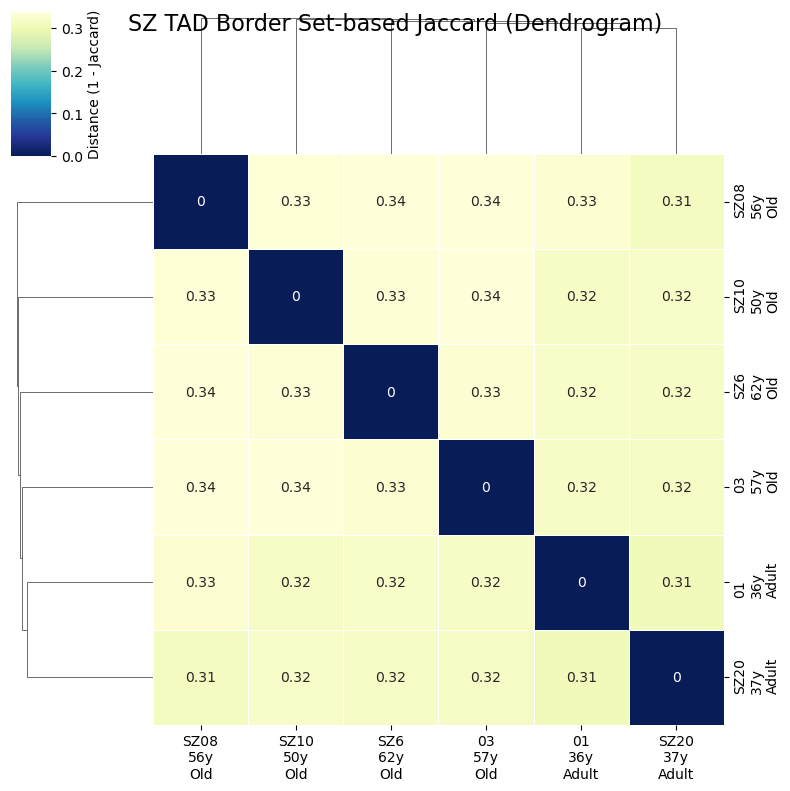

In [114]:
def make_label(label):
    age = samples_with_age[label]
    group = age_group[label]
    short = label.replace('HC-', '').replace('SZ-', '')
    return f"{short}\n{age}y\n{group}"

def plot_clustermap(matrix, labels, title, samples_with_age):
    annotated_labels = [make_label(lab) for lab in labels]
    distance_matrix = 1 - matrix
    df = pd.DataFrame(distance_matrix, index=annotated_labels, columns=annotated_labels)
    cg = sns.clustermap(
        df,
        cmap='YlGnBu_r',  # reverse colormap: low distance = dark
        linewidths=0.5,
        figsize=(8, 8),
        annot=True,
        cbar_kws={"label": "Distance (1 - Jaccard)"},
        metric='euclidean',  # or 'precomputed'
        method='average'
    )
    plt.suptitle(title, fontsize=16)
    plt.show()

# Example usage:
plot_clustermap(hc_matrix, hc_labels, 'HC TAD Border Set-based Jaccard (Dendrogram)', samples_with_age)
plot_clustermap(sz_matrix, sz_labels, 'SZ TAD Border Set-based Jaccard (Dendrogram)', samples_with_age)

In [188]:
hc_labels = [extract_sample_name(os.path.basename(f)) for f in hc_beds]
sz_labels = [extract_sample_name(os.path.basename(f)) for f in sz_beds]
hc_labels

['HC-2M', 'HC-318', 'HC-3M', 'HC-91', 'HC24', 'HCM12']

Mann-Whitney U statistic: 272.000
p-value: 8.657e-03
HC mean: 0.655, median: 0.652
SZ mean: 0.676, median: 0.680


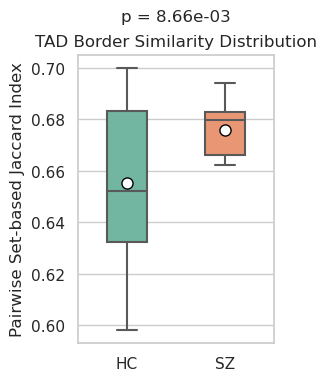

In [134]:
hc_similarities = get_off_diagonal(hc_matrix)
sz_similarities = get_off_diagonal(sz_matrix)

stat, p_value = mannwhitneyu(hc_similarities, sz_similarities, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.3f}")
print(f"p-value: {p_value:.3e}")

print(f"HC mean: {np.mean(hc_similarities):.3f}, median: {np.median(hc_similarities):.3f}")
print(f"SZ mean: {np.mean(sz_similarities):.3f}, median: {np.median(sz_similarities):.3f}")

plt.figure(figsize=(3, 4))
sns.boxplot(
    data=[hc_similarities, sz_similarities],
    
    width=0.4,
    palette='Set2',
    # palette={'HC': 'skyblue', 'SZ': 'salmon'},
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    }
)
plt.xticks([0, 1], ['HC', 'SZ'])
plt.ylabel('Pairwise Set-based Jaccard Index')
plt.title('TAD Border Similarity Distribution')

plt.text(0.5, max(max(hc_similarities), max(sz_similarities)) + 0.017,
         f'p = {p_value:.2e}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
def pairwise_similarity_df(matrix, labels):
    data = []
    n = len(labels)
    for i in range(n):
        for j in range(i+1, n):
            sim = matrix[i, j]
            label_i, label_j = labels[i], labels[j]
            group_i, group_j = get_group(label_i), get_group(label_j)
            age_i, age_j = age_group[label_i], age_group[label_j]
            data.append({
                'sample1': label_i, 'sample2': label_j,
                'group1': group_i, 'group2': group_j,
                'age_group1': age_i, 'age_group2': age_j,
                'similarity': sim
            })
    return pd.DataFrame(data)

def get_group(label):
    if label.startswith('HC'):
        return 'HC'
    elif label.startswith('SZ'):
        return 'SZ'
    else:
        return 'Unknown'

samples_with_age = {
    'HC-2M': 62, 'HC-3M': 36, 'HC-91': 59, 'HC24': 54, 'HC-318': 58, 'HCM12': 35,
    'SZ-01': 36, 'SZ-03': 57, 'SZ08': 56, 'SZ10': 50, 'SZ20': 37, 'SZ6': 62
}
age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Adult"
    elif 40 < age <= 57:
        age_group[label] = "Old"
    else:
        age_group[label] = "Old"

hc_df = pairwise_similarity_df(hc_matrix, hc_labels)
sz_df = pairwise_similarity_df(sz_matrix, sz_labels)
all_df = pd.concat([hc_df, sz_df], ignore_index=True)

In [215]:
age_comparison = ['Adult-Old', 'Old-Old', 'Adult-Adult']

all_df['comparison'] = all_df['age_group1'] + all_df['age_group2']
age_comparison_list = []
for i in all_df['comparison']:
    if "Adult" in i and "Old" in i:
        age_comparison_list.append('Adult-Old')
    elif "Adult" in i and "Old" not in i:
        age_comparison_list.append('Adult-Adult')
    else:
        age_comparison_list.append('Old-Old')
all_df['comparison'] = age_comparison_list
all_df['group'] = all_df['group2']


In [ ]:
plt.figure(figsize=(6, 4.5))
ax = sns.boxplot(
    data=all_df,
    x="comparison",
    y="similarity",
    hue="group",
    order=['Adult-Adult', 'Adult-Old', 'Old-Old'],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    },
    width=0.5,
    palette='Set2'
)

plt.ylabel('Pairwise Set-based Jaccard Index')
plt.title('TAD Border Similarity: Group-Age Comparisons')
plt.tight_layout()

hue_order = all_df["group"].unique()
x_order = ['Adult-Adult', 'Adult-Old', 'Old-Old']

for i, x_val in enumerate(x_order):
    data = all_df[all_df['comparison'] == x_val]
    groups = data['group'].unique()
    if len(groups) < 2:
        continue
    vals = []
    for g in groups:
        vals.append(data[data['group'] == g]['similarity'].values)
    if all([len(v) >= 2 for v in vals]):
        stat, pval = stats.mannwhitneyu(vals[0], vals[1], alternative='two-sided')
        y_max = max([np.max(v) if len(v) > 0 else 0 for v in vals])
        y_min = min([np.min(v) if len(v) > 0 else 0 for v in vals])
        y = 0.7
        ax.text(i, y, f"p={pval:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.savefig(f'./tads_visualizations/neurons_tad_borders_similiarity_by_age_gorups.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

## Border Strength Variability

In [ ]:
merged_bed['group'] = merged_bed['source'].str.extract(r'^(HC|SZ)', expand=False)

In [128]:
sd_df = (
    merged_bed[['group', 'cluster', 'boundary_strength_150000']].drop_duplicates()
    .groupby(['group', 'cluster'])['boundary_strength_150000']
    .std()
    .reset_index()
    .rename(columns={'boundary_strength_150000': 'SD_boundary_strength'})
)

sz_sd = sd_df.query('group == "SZ"')['SD_boundary_strength']
hc_sd = sd_df.query('group == "HC"')['SD_boundary_strength']

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=sd_df,
    x='group',
    y='SD_boundary_strength',
    width =0.4,
    showfliers=False,
    palette='Set2',
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    }
)

t_stat, p_val = ttest_ind(hc_sd.dropna(), sz_sd.dropna(), equal_var=False)
print(f"T-test: t = {t_stat:.3f}, p = {p_val:.3g}")

plt.text(0.5, 0.44,
         f'p = {p_val:.2e}', ha='center', va='bottom', fontsize=12)

plt.title('Distribution of SD(boundary strength) per Cluster by Group')
plt.ylabel('Standard Deviation of Boundary Strength')
plt.xlabel('Group')
plt.show()